<a href="https://colab.research.google.com/github/Caffeinboy/simple_neuralnetwork/blob/main/simple_neural_network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [67]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [71]:
#create a model class that inherits the nn.module
class Model(nn.Module):
#input layer(4 features of the flower)-->
#hidden layer1 (number of neurons)-->
#h2 (n)-->
#output(3 classes of flower)
    def __init__(self,in_features=4,h1=8,h2=8,out_features=3):
        super(Model, self).__init__() #instantiate the module
        self.fc1=nn.Linear(in_features,h1)
        self.fc2=nn.Linear(h1,h2)
        self.out=nn.Linear(h2,out_features)

    def forward(self,x):
      x=F.relu(self.fc1(x))
      x=F.relu(self.fc2(x))
      x=self.out(x)
      return x

In [73]:
torch.manual_seed(41)
model=Model()

In [74]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [75]:
url = 'https://gist.githubusercontent.com/curran/a08a1080b88344b0c8a7/raw/0e7a9b0a5d22642a06d3d5b9bcbad9890c8ee534/iris.csv'
my_df = pd.read_csv(url)

In [76]:
my_df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [77]:
my_df['species'] = my_df['species'].replace('setosa',0.0)
my_df['species'] = my_df['species'].replace('versicolor',1.0)
my_df['species'] = my_df['species'].replace('virginica',2.0)

/tmp/ipython-input-3151340200.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  my_df['species'] = my_df['species'].replace('virginica',2.0)


In [78]:
my_df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2.0
146,6.3,2.5,5.0,1.9,2.0
147,6.5,3.0,5.2,2.0,2.0
148,6.2,3.4,5.4,2.3,2.0


In [79]:
#train test model
x= my_df.drop('species',axis=1)
y= my_df['species']

In [80]:
#convert to numpy
x = x.values
y = y.values

In [81]:
from sklearn.model_selection import train_test_split

In [82]:
#Train test split
x_train,x_test,y_train,y_test = train_test_split(x, y, test_size=0.2, random_state=41)

In [83]:
#convert x features to float tensors
x_train = torch.FloatTensor(x_train)
x_test = torch.FloatTensor(x_test)


In [84]:
#convert y labels to tensors long
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

In [85]:
#set the criteria of the model to measure the error,how far off the predicytion are from
criterion = nn.CrossEntropyLoss()
#choose optimizer,Ir = learning rate(if error doesn't go down after a bunch of iteration(epochs),lower the learning rate)
optimizer = torch.optim.Adam(model.parameters(),lr=0.01)


In [92]:
#Train our model
#Epochs (one run thru all the training data in our network)
epochs = 200
losses = []
for i in range(epochs):
  #go forward & get a prediction
  y_pred = model(x_train)#get predicted results

  loss = criterion(y_pred,y_train)#measure the loss/error,gonna be high at first

  #keep tract of losses
  losses.append(loss.detach().numpy())

  #print every 10 epochs
  if i % 10 == 0:
    print(f'Epoch: {i} and Loss: {loss}')

  #do some back propagation: take the error rate of forward prpogation &
  #feed it back thru the network to fine tune the weights
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

Epoch: 0 and Loss: 0.005358545109629631
Epoch: 10 and Loss: 0.005212139803916216
Epoch: 20 and Loss: 0.005069284699857235
Epoch: 30 and Loss: 0.004928715527057648
Epoch: 40 and Loss: 0.004796077497303486
Epoch: 50 and Loss: 0.004666946362704039
Epoch: 60 and Loss: 0.004541411530226469
Epoch: 70 and Loss: 0.004419542383402586
Epoch: 80 and Loss: 0.004301196429878473
Epoch: 90 and Loss: 0.0041862791404128075
Epoch: 100 and Loss: 0.004074678756296635
Epoch: 110 and Loss: 0.003966336604207754
Epoch: 120 and Loss: 0.0038611283525824547
Epoch: 130 and Loss: 0.003758964827284217
Epoch: 140 and Loss: 0.003659817622974515
Epoch: 150 and Loss: 0.003563565667718649
Epoch: 160 and Loss: 0.0034701330587267876
Epoch: 170 and Loss: 0.0033794408664107323
Epoch: 180 and Loss: 0.003291437868028879
Epoch: 190 and Loss: 0.003206009278073907


Text(0.5, 0, 'Epoch')

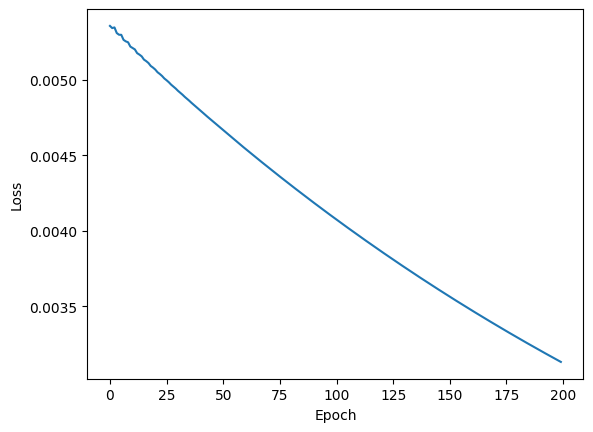

In [93]:
plt.plot(range(epochs),losses)
plt.ylabel('Loss')
plt.xlabel('Epoch')

In [94]:
#evaluate model on test data set
with torch.no_grad():
  y_eval = model(x_test)
  loss = criterion(y_eval,y_test)

In [95]:
loss

tensor(0.4261)

In [101]:
correct = 0
with torch.no_grad():
  for i,data in enumerate(x_test):
    y_val = model.forward(data)

    if y_test[i] == 0.0:
     x = 'setosa'
    elif y_test[i] == 1.0:
     x = 'versicolor'
    else:
     x = 'virginica'

    print(f'{i+1}. {str(y_val)} \t {x} \t {y_val.argmax().item()}')
    if y_val.argmax().item() == y_test[i]:
      correct += 1
print(f'\n{correct} out of {len(y_test)} = {100*correct/len(y_test)}% correct')

1. tensor([-13.1676,   1.2830,  12.6114]) 	 virginica 	 2
2. tensor([-17.7286,  -4.4736,  22.7044]) 	 virginica 	 2
3. tensor([-20.3188,  -5.0129,  25.9629]) 	 virginica 	 2
4. tensor([-4.0458, 10.3440, -5.8270]) 	 versicolor 	 1
5. tensor([-17.1024,  -2.2968,  20.0688]) 	 virginica 	 2
6. tensor([  0.5173,  11.9559, -12.5631]) 	 versicolor 	 1
7. tensor([-13.0045,   2.6145,  11.2266]) 	 virginica 	 2
8. tensor([-3.7269, 10.4489, -6.2907]) 	 versicolor 	 1
9. tensor([-15.4693,  -0.5635,  16.7446]) 	 virginica 	 2
10. tensor([-18.9568,  -5.1572,  24.6165]) 	 virginica 	 2
11. tensor([-11.6047,   4.5286,   7.9910]) 	 virginica 	 2
12. tensor([ 33.5448,  24.0816, -62.0103]) 	 setosa 	 0
13. tensor([ 30.7201,  22.0691, -56.8190]) 	 setosa 	 0
14. tensor([  4.0881,  11.6049, -16.2577]) 	 versicolor 	 1
15. tensor([ 28.8889,  21.5192, -53.9972]) 	 setosa 	 0
16. tensor([-9.8497,  7.8391,  3.1114]) 	 virginica 	 1
17. tensor([ 30.8732,  22.1849, -57.1019]) 	 setosa 	 0
18. tensor([-12.5508,  

In [102]:
new_iris = torch.tensor([4.7,3.2,1.3,0.2])

In [103]:
with torch.no_grad():
  print(model(new_iris))

tensor([ 32.4688,  23.3124, -60.0323])


In [105]:
newer_iris = torch.tensor([6.5,3.0,5.2,2.0])


In [106]:
with torch.no_grad():
  print(model(newer_iris))

tensor([-15.4693,  -0.5635,  16.7446])


In [107]:
#save our NN model
torch.save(model.state_dict(),'iris_model.pt')

In [108]:
#load saved model
new_model = Model()
new_model.load_state_dict(torch.load('iris_model.pt'))

<All keys matched successfully>

In [110]:
#make sure loaded correct
new_model.eval()

Model(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=8, bias=True)
  (out): Linear(in_features=8, out_features=3, bias=True)
)